In [13]:
import pandas as pd

df = pd.read_csv("spotify_top_1000_tracks.csv") 

                                          track_name                 artist  \
710                                         Lost Boy                  Jaden   
610                                I'm Getting Ready    Tasha Cobbs Leonard   
64                                           Mirrors      Justin Timberlake   
63   What Goes Around.../...Comes Around (Interlude)      Justin Timberlake   
622                               Achilles Come Down         Gang of Youths   
689                             Never Let Go (Of Me)                 Baltra   
682            House Of Balloons / Glass Table Girls             The Weeknd   
549                                             Stan                 Eminem   
671                                        Galvanize  The Chemical Brothers   
37                                       After Hours             The Weeknd   

     duration_min  
710      9.497883  
610      8.436667  
64       8.069100  
63       7.476217  
622      7.035767  
689      6

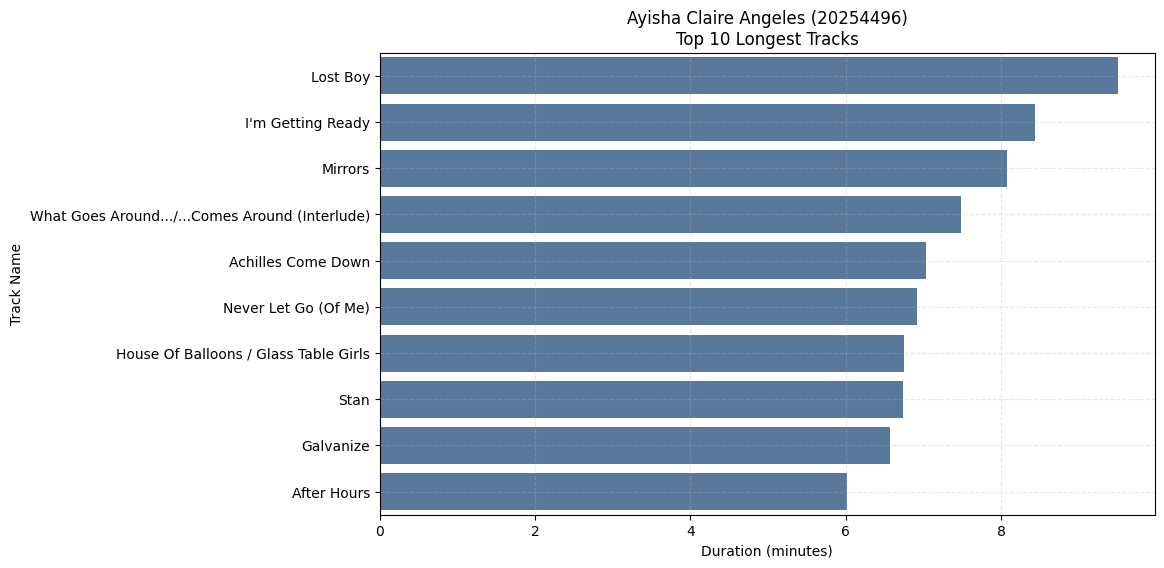

In [14]:
# 1. Identify Longest Tracks 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# -----------------------------
# Student-specific parameters
# -----------------------------
student_name = "Ayisha Claire Angeles"
student_id = "20254496"

# Example student-specific color (replace if required)
color_bar = "#4E79A7"

# -----------------------------
# Load and clean data
# -----------------------------
df = pd.read_csv("spotify_top_1000_tracks.csv")  # replace with actual filename
df.columns = df.columns.str.strip()

df['duration_min'] = pd.to_numeric(df['duration_min'], errors='coerce')

df_clean = df.dropna(subset=['track_name', 'artist', 'duration_min'])

# -----------------------------
# Calculations
# -----------------------------
top_10 = df_clean.sort_values(by='duration_min', ascending=False).head(10)

# Display table output
print(top_10[['track_name', 'artist', 'duration_min']])

# -----------------------------
# Visualization
# -----------------------------
plt.figure(figsize=(10, 6))

sns.barplot(
    data=top_10,
    x='duration_min',
    y='track_name',
    color=color_bar
)

plt.title(f"{student_name} ({student_id})\nTop 10 Longest Tracks")
plt.xlabel("Duration (minutes)")
plt.ylabel("Track Name")

plt.grid(True, linestyle='--', alpha=0.3)

plt.show()

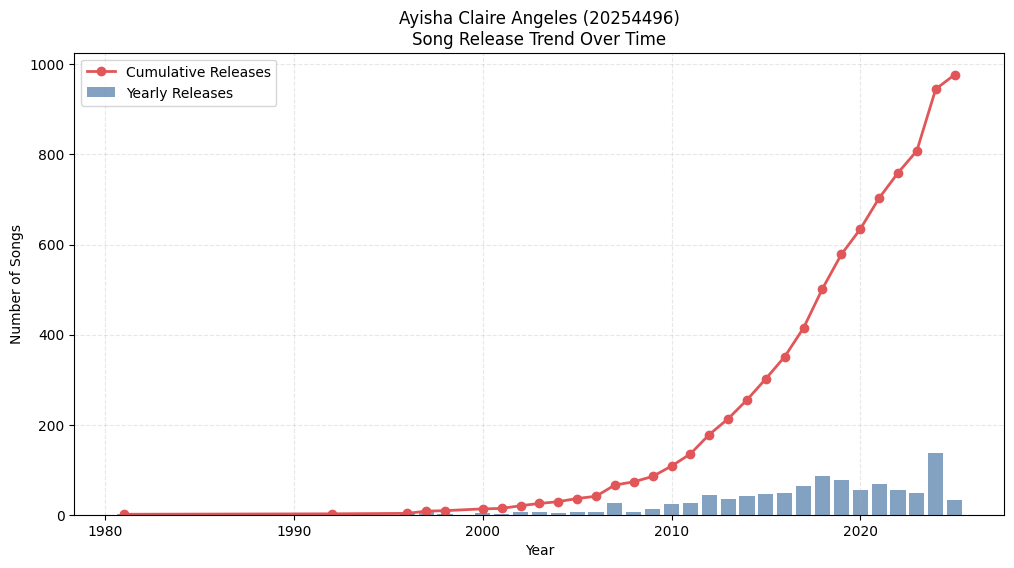

In [15]:
# 2. Song Release Trend 
import pandas as pd
import matplotlib.pyplot as plt

# -----------------------------
# Student-specific parameters
# -----------------------------
student_name = "Ayisha Claire Angeles"
student_id = "20254496"

color_bar = "#4E79A7"
color_line = "#E15759"

# -----------------------------
# Load and clean data
# -----------------------------
df = pd.read_csv("spotify_top_1000_tracks.csv")  
df.columns = df.columns.str.strip()

# Convert release_date to year
df['release_date'] = pd.to_datetime(df['release_date'], errors='coerce')
df['year'] = df['release_date'].dt.year

# Remove invalid years
df_clean = df.dropna(subset=['year'])

# -----------------------------
# Calculations
# -----------------------------
# Songs released per year
yearly_counts = df_clean['year'].value_counts().sort_index()

# Cumulative count
cumulative_counts = yearly_counts.cumsum()

# -----------------------------
# Plot
# -----------------------------
plt.figure(figsize=(12, 6))

# Bar chart (yearly counts)
plt.bar(
    yearly_counts.index,
    yearly_counts.values,
    color=color_bar,
    alpha=0.7,
    label="Yearly Releases"
)

# Line chart (cumulative)
plt.plot(
    cumulative_counts.index,
    cumulative_counts.values,
    color=color_line,
    marker='o',
    linewidth=2,
    label="Cumulative Releases"
)

# Labels and title
plt.title(f"{student_name} ({student_id})\nSong Release Trend Over Time")
plt.xlabel("Year")
plt.ylabel("Number of Songs")

plt.grid(True, linestyle='--', alpha=0.3)
plt.legend()

plt.show()

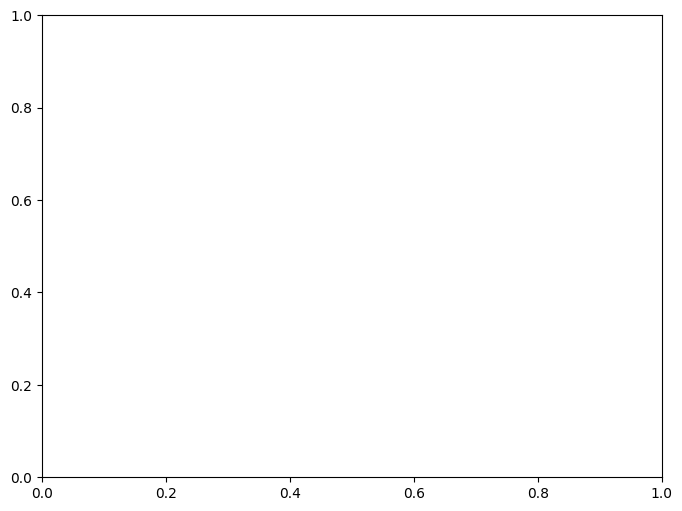

In [16]:
# 3. Animated Density Map of Duration vs Popularity 
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.animation as animation

# -----------------------------
# Student-specific parameters
# -----------------------------
student_name = "Ayisha Claire Angeles"
student_id = "20254496"
cmap_color = "viridis"

# -----------------------------
# Load and clean data
# -----------------------------
df = pd.read_csv("spotify_top_1000_tracks.csv")  
df.columns = df.columns.str.strip()

df['release_date'] = pd.to_datetime(df['release_date'], errors='coerce')
df['year'] = df['release_date'].dt.year

df['duration_min'] = pd.to_numeric(df['duration_min'], errors='coerce')
df['popularity'] = pd.to_numeric(df['popularity'], errors='coerce')

df_clean = df.dropna(subset=['year', 'duration_min', 'popularity'])

years = sorted(df_clean['year'].unique())

# -----------------------------
# Figure setup
# -----------------------------
fig, ax = plt.subplots(figsize=(8, 6))

def update(year):
    ax.clear()

    data = df_clean[df_clean['year'] == year]

    ax.hexbin(
        data['duration_min'],
        data['popularity'],
        gridsize=30,
        cmap=cmap_color,
        mincnt=1
    )

    ax.set_title(f"{student_name} ({student_id})\nDuration vs Popularity ({int(year)})")
    ax.set_xlabel("Duration (min)")
    ax.set_ylabel("Popularity")

    ax.grid(True, linestyle='--', alpha=0.3)

# -----------------------------
# Animation
# -----------------------------
ani = animation.FuncAnimation(
    fig,
    update,
    frames=years,
    interval=800,
    repeat=True
)

plt.show()